In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
from pathlib import Path

In [4]:
img_path = Path("data") / "peppers-large.tiff"
A = imread(img_path)

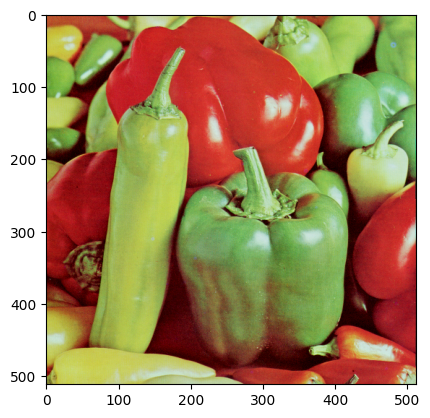

In [5]:
plt.imshow(A)
plt.show()

In [9]:
#Color value for each pixel
red_color = A[:,:,0].flatten()
green_color = A[:,:,1].flatten()
blue_color = A[:,:,2].flatten()

In [10]:
#Matrix cotaining rgb tuple for each pixel
rgb_per_pixel = np.column_stack((red_color, green_color, blue_color))

In [12]:
#We initialice the mean of each cluster
X1 = np.random.randint(low=0, high=262144, size=(16,))
mu = np.array([rgb_per_pixel[i] for i in X1])

In [13]:
#Run K-mean
it = 1
ll = prev_ll = None
while it < 16 and (prev_ll is None or np.abs(ll - prev_ll) >= 1e5):
    print(f"Iteration: {it}")
    nom_matrix = np.linalg.norm(
        rgb_per_pixel[None, :, :] - mu[:, None, :],
        axis=2
    )

    c = np.argmin(nom_matrix, axis=0)

    rgb_per_pixel = rgb_per_pixel.astype(np.float64)
    mu = mu.astype(np.float64)

    for j in range(16):
        denom = len(np.where(c == j)[0])
        suma = 0
        for i in range(262144):
            suma_2 = 0
            if c[i] != j:
                suma += 0
            else:
                suma += rgb_per_pixel[i]/denom
            
        mu[j] = suma
    
    prev_ll = ll
    final_compression = np.zeros((262144, 3))
    for i, j in enumerate(c):
        final_compression[i,:] = mu[int(j)]

    ll = np.sum(np.linalg.norm(final_compression - rgb_per_pixel, axis=1)**2)
    print(f"Loss: {ll:.4f}")
    it+=1

Iteration: 1
Loss: 1107720758.6764
Iteration: 2
Loss: 173767031.3998
Iteration: 3
Loss: 133471970.5950
Iteration: 4
Loss: 123546540.8061
Iteration: 5
Loss: 118233835.3394
Iteration: 6
Loss: 115657839.6415
Iteration: 7
Loss: 113739107.4482
Iteration: 8
Loss: 112571766.6482
Iteration: 9
Loss: 111856433.5141
Iteration: 10
Loss: 111363099.0116
Iteration: 11
Loss: 110984853.8714
Iteration: 12
Loss: 110689927.3110
Iteration: 13
Loss: 110457758.9092
Iteration: 14
Loss: 110276589.6607
Iteration: 15
Loss: 110133396.5800


In [14]:
final_image = final_compression.reshape(A.shape)
final_image = final_image.astype(np.uint8)

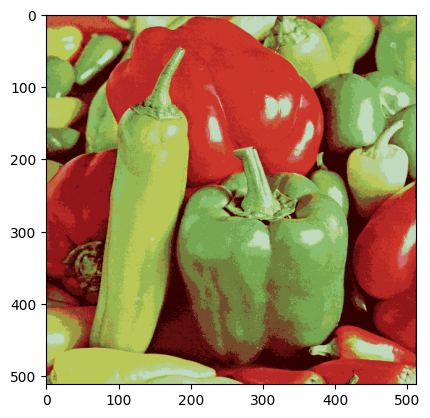

In [15]:
plt.imshow(final_image)
plt.show()